In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import nltk
from nltk.corpus import stopwords
import string
import re  
from spellchecker import SpellChecker 
from sklearn.linear_model import LogisticRegression


In [2]:
# Cell 2: Download NLTK Stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Guransh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
# Cell 3: Load the Dataset
data = pd.read_csv("IMDB_Dataset.csv")  
print(data.head())  


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [4]:
# Cell 4: Data Cleaning - Lowercasing and HTML Removal
data['review'] = data['review'].str.lower()  # Convert all reviews to lowercase

def remove_html_tags(text): 
    clean = re.compile('<.*?>')
    return clean.sub('', text)

data['review'] = data['review'].apply(remove_html_tags)

print(data['review'].head()) 


0    one of the other reviewers has mentioned that ...
1    a wonderful little production. the filming tec...
2    i thought this was a wonderful way to spend ti...
3    basically there's a family where a little boy ...
4    petter mattei's "love in the time of money" is...
Name: review, dtype: object


In [5]:
# Cell 5: Data Cleaning - URL, Punctuation, and Negation Handling

def remove_urls(text):  
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

PUNCT_TO_REMOVE = string.punctuation  

def remove_punctuation(text):  
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

def handle_negations(text):
    negations = ["not", "no", "never", "n't", "cannot", "won't", "wouldn't", "couldn't", "shouldn't", "isn't", "wasn't", "doesn't", "don't", "didn't", "can't"]
    words = text.split()
    new_words = []
    skip_next = False
    
    for i in range(len(words) - 1):
        if skip_next:
            skip_next = False
            continue
        if any(neg in words[i] for neg in negations): 
            new_word = words[i] + '_' + words[i + 1]  
            new_words.append(new_word)
            skip_next = True
        else:
            new_words.append(words[i])

    if not skip_next:
        new_words.append(words[-1])  

    return ' '.join(new_words)


# Apply all cleaning functions again
data['review'] = data['review'].apply(remove_urls)
data['review'] = data['review'].apply(remove_punctuation)
data['review'] = data['review'].apply(handle_negations)  


print(data['review'].head())


0    one of the other reviewers has mentioned that ...
1    a wonderful little production the filming tech...
2    i thought this was a wonderful way to spend ti...
3    basically theres a family where a little boy j...
4    petter matteis love in the time of money is a ...
Name: review, dtype: object


In [6]:

# Retain negation words in stopwords removal
STOPWORDS = set(stopwords.words('english')) - {"not", "no", "nor", "never"}

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

data['review'] = data['review'].apply(remove_stopwords)

print(data['review'].head())


0    one reviewers mentioned watching 1 oz episode ...
1    wonderful little production filming technique ...
2    thought wonderful way spend time hot summer we...
3    basically theres family little boy jake thinks...
4    petter matteis love time money visually stunni...
Name: review, dtype: object


In [7]:
# Cell 8: Feature Extraction (Bag of Words)
'''cv = CountVectorizer() # Initialize the CountVectorizer
X = cv.fit_transform(data['review']) # Fit and transform the review text
y = data['sentiment'] # Assuming 'rating' is the sentiment label (target variable)

print(X.shape) #check the shape of X
print(y.shape) #check the shape of y'''

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1, 3), min_df=1, max_df=0.9)

# Transform the updated data
X = tfidf.fit_transform(data['review'])
y = data['sentiment']

print(X.shape, y.shape)


(50000, 9148020) (50000,)


              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4961
    positive       0.87      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



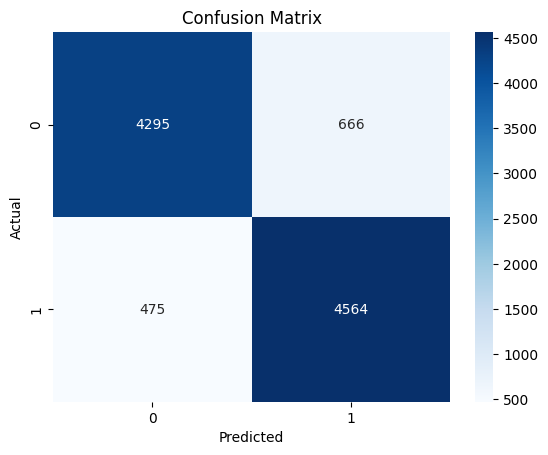

In [8]:
# Cell 9: Train-Test Split
'''X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape) #check the shape of X_train
print(X_test.shape) #check the shape of X_test

# Cell 10: Train the Naive Bayes Model
model = MultinomialNB() # Initialize the Naive Bayes model
model.fit(X_train, y_train) # Train the model

# Cell 11: Make Predictions and Evaluate
y_pred = model.predict(X_test) # Make predictions on the test set
print(classification_report(y_test, y_pred)) # Print the classification report
cm = confusion_matrix(y_test, y_pred) # Create the confusion matrix
sns.heatmap(cm, annot=True) # Plot the confusion matrix
plt.show()'''

# Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Logistic Regression Model
model = LogisticRegression(max_iter=1000) 
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, target_names=['negative', 'positive'], output_dict=True)
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


C:\Users\Guransh\AppData\Local\Temp\ipykernel_28036\1897419101.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


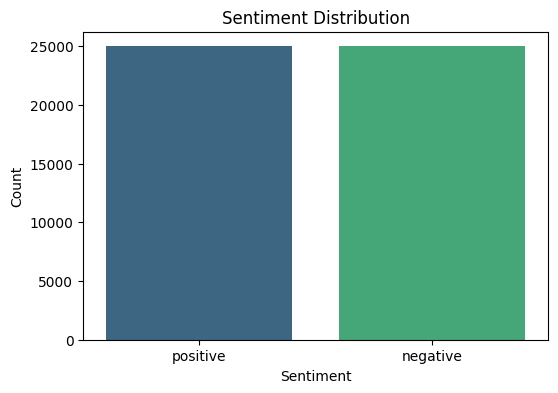

In [9]:
# Check the distribution of sentiments in the dataset
sentiment_counts = data['sentiment'].value_counts()
print(sentiment_counts)

# Visualize the sentiment distribution
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


In [10]:
# Cell 12: Predict on New Reviews (with user input)

# Get input from the user
'''new_review = input("Enter a movie review: ")

# Preprocess the new review
new_review = new_review.lower()
new_review = remove_html_tags(new_review)
new_review = remove_urls(new_review)
new_review = remove_punctuation(new_review)
new_review = remove_stopwords(new_review)
# new_review = correct_spellings(new_review)  # Uncomment if you used it before

# Transform the preprocessed review using the same CountVectorizer
new_review_transformed = cv.transform([new_review])  # Note: transform expects a list

# Make the prediction
prediction = model.predict(new_review_transformed)

# Print the prediction
print("Prediction for your review:", prediction)'''

'''# Predict on New Reviews (with user input)

# Get input from the user
new_review = input("Enter a movie review: ")

# Preprocess the review
new_review = new_review.lower()
new_review = remove_html_tags(new_review)
new_review = remove_urls(new_review)
new_review = remove_punctuation(new_review)
new_review = handle_negations(new_review)  # Ensure negation handling
new_review = remove_stopwords(new_review)

# Transform and predict using updated TF-IDF
new_review_transformed = tfidf.transform([new_review])
# Make the prediction
prediction = model.predict(new_review_transformed)

# Print the prediction
print("Prediction for your review:", prediction)'''

# List of test reviews
new_reviews = [
    "The movie was so good",
    "The movie is not bad, actually quite enjoyable.",
    "The movie was absolutely fantastic and I loved every minute of it.",  # Clearly positive
    "This was a terrible movie, I regret watching it.",  # Clearly negative
    "The movie is not bad, actually quite enjoyable.",  # Negation (should be positive)
    "I wouldn't recommend this movie to anyone.",  # Negation (should be negative)
    "It was just okay, nothing special.",  # Neutral/ambiguous
    "An outstanding film with brilliant acting and direction.",  # Positive
    "Not good at all, very disappointing experience.",  # Negation (should be negative)
    "I really enjoyed the cinematography, but the story was weak.",  # Mixed
    "Worst movie I've ever seen, complete waste of time.",  # Strong negative
    "The plot was not interesting, but the visuals were stunning."  # Mixed with negation
]

# Preprocess each review individually
processed_reviews = []
for review in new_reviews:
    review = review.lower() 
    review = remove_html_tags(review)  
    review = remove_urls(review)  
    review = handle_negations(review)  
    review = remove_punctuation(review)  
    review = remove_stopwords(review)  
    processed_reviews.append(review)


# Transform the list of processed reviews using TF-IDF
new_reviews_transformed = tfidf.transform(processed_reviews)

# Make predictions for all reviews
predictions = model.predict(new_reviews_transformed)

# Print each review with its corresponding prediction
for i, review in enumerate(new_reviews):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {predictions[i]}")
    print("-" * 60)




Review: The movie was so good
Predicted Sentiment: positive
------------------------------------------------------------
Review: The movie is not bad, actually quite enjoyable.
Predicted Sentiment: positive
------------------------------------------------------------
Review: The movie was absolutely fantastic and I loved every minute of it.
Predicted Sentiment: positive
------------------------------------------------------------
Review: This was a terrible movie, I regret watching it.
Predicted Sentiment: negative
------------------------------------------------------------
Review: The movie is not bad, actually quite enjoyable.
Predicted Sentiment: positive
------------------------------------------------------------
Review: I wouldn't recommend this movie to anyone.
Predicted Sentiment: negative
------------------------------------------------------------
Review: It was just okay, nothing special.
Predicted Sentiment: negative
--------------------------------------------------------

In [11]:
import pickle

with open('sentiment_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

with open('tfidf_vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(tfidf, vectorizer_file)

with open('model_metrics.pkl', 'wb') as metrics_file:
    pickle.dump({'classification_report': report, 'confusion_matrix': cm}, metrics_file)
